In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Eksik Veri Kontrolü
print("Missing values:")
print(df.isnull().sum())


# 3. Zaman Serisi Görselleştirme
#plt.figure(figsize=(12, 6))
#plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
#plt.xlabel("Time")
#plt.ylabel("Value")
#plt.title("Time Series Plot of 0_x")
#plt.legend()
#plt.grid(True)
#plt.show()

Missing values:
time    0
0_x     0
dtype: int64


In [15]:
# 4. ADF Durağanlık Testi
# adf_test = adfuller(df['0_x'])
# print("ADF Statistic:", adf_test[0])
# print("p-value:", adf_test[1])
# print("Critical Values:", adf_test[4])

# Durağan olup olmadığını kontrol etme
# if adf_test[1] < 0.05:
    # print("Sonuç: Seri durağandır (Stationary)")
# else:
    # print("Sonuç: Seri durağan değildir (Non-Stationary)")

In [17]:
# 5. ACF ve PACF Grafikleri
# fig, ax = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(df['0_x'].dropna(), ax=ax[0], lags=20)
# ax[0].set_title("Autocorrelation Function (ACF)")
# plot_pacf(df['0_x'].dropna(), ax=ax[1], lags=20)
# ax[1].set_title("Partial Autocorrelation Function (PACF)")
# plt.tight_layout()
# plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.7746503594867
Gerçek: 630, Tahmin: 631.7746503594867
Gerçek: 628, Tahmin: 631.7746503594867
Gerçek: 627, Tahmin: 631.7746503594867
Gerçek: 627, Tahmin: 631.7746503594867
Gerçek: 627, Tahmin: 631.7746503594867
Gerçek: 627, Tahmin: 631.7746503594867
Gerçek: 626, Tahmin: 631.7746503594867
Gerçek: 626, Tahmin: 631.7746503594867
Gerçek: 625, Tahmin: 631.7746503594867
Gerçek: 624, Tahmin: 631.7746503594867
Gerçek: 624, Tahmin: 631.7746503594867
Gerçek: 623, Tahmin: 631.7746503594867
Gerçek: 623, Tahmin: 631.7746503594867
Gerçek: 622, Tahmin: 631.7746503594867
Gerçek: 622, Tahmin: 631.7746503594867
Gerçek: 622, Tahmin: 631.7746503594867
Gerçek: 622, Tahmin: 631.7746503594867
Gerçek: 620, Tahmin: 631.7746503594867
Gerçek: 620, Tahmin: 631.7746503594867
Gerçek: 619, Tahmin: 631.7746503594867
Gerçek: 620, Tahmin: 631.7746503594867
Gerçek: 620, Tahmin: 631.7746503594867
Gerçek: 620, Tahmin: 631.7746503594867
Gerçek: 620, Tahmin: 

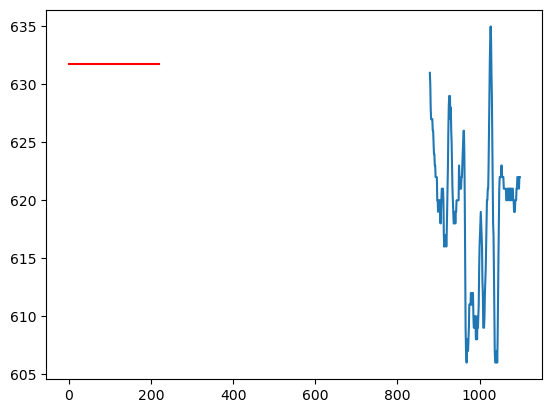

In [25]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast().iloc[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

In [ ]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(train, order=(5, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast().iloc[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

In [ ]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(train, order=(10, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast().iloc[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

In [ ]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(train, order=(20, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast().iloc[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

In [ ]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(train, order=(30, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast().iloc[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()